# Dependency Installation
Installing required libraries for ASR benchmarking.



In [1]:
!pip install -q openai-whisper
!pip install -q google-cloud-speech
!pip install -q transformers
!pip install -q torchaudio
!pip install -q datasets
!pip install -q jiwer
!pip install -q pandas
!pip install -q matplotlib
!pip install -q librosa
!pip install -q soundfile

# Imports
Loading required Python libraries.

In [2]:
import os
import time
import pandas as pd
import numpy as np

from jiwer import wer, cer

import whisper
import librosa
import soundfile as sf

import matplotlib.pyplot as plt

In [3]:
os.makedirs("audio", exist_ok=True)
os.makedirs("outputs", exist_ok=True)
os.makedirs("results", exist_ok=True)

print("Folders created.")

Folders created.


# Evaluation Metrics
Implemented metrics:
- WER
- CER
- Latency
- Real-Time Factor (RTF)
- Entity Accuracy
- Hallucination Rate

In [4]:
whisper_model = whisper.load_model("small")

print("Whisper Small loaded.")

Whisper Small loaded.


In [5]:
!pip uninstall -y deepgram-sdk
!pip install deepgram-sdk==3.2.7

Found existing installation: deepgram-sdk 3.2.7
Uninstalling deepgram-sdk-3.2.7:
  Successfully uninstalled deepgram-sdk-3.2.7
  Using cached deepgram_sdk-3.2.7-py3-none-any.whl.metadata (12 kB)
Using cached deepgram_sdk-3.2.7-py3-none-any.whl (80 kB)


In [6]:
from deepgram import DeepgramClient, PrerecordedOptions

from google.colab import userdata

DEEPGRAM_API = userdata.get('DEEPGRAM_API')

deepgram = DeepgramClient(DEEPGRAM_API)

print("Deepgram initialized.")

Deepgram initialized.


# Deepgram Transcription Function


In [7]:
def transcribe_deepgram(audio_path):
    start = time.time()

    with open(audio_path, "rb") as file:
        buffer_data = file.read()

    payload = {
        "buffer": buffer_data
    }

    options = PrerecordedOptions(
        model="nova-2",
        smart_format=True,
    )

    response = deepgram.listen.prerecorded.v("1").transcribe_file(
        payload,
        options
    )

    end = time.time()

    transcript = response["results"]["channels"][0]["alternatives"][0]["transcript"]

    latency = end - start

    return transcript, latency

# Whisper Small Transcription Function

In [9]:
def transcribe_whisper(audio_path):

    start = time.time()

    result = whisper_model.transcribe(audio_path)

    end = time.time()

    transcript = result["text"]

    latency = end - start

    return transcript, latency

In [12]:
from transformers import pipeline

vakyansh_asr = pipeline(
    task="automatic-speech-recognition",
    model="Harveenchadha/vakyansh-wav2vec2-hindi-him-4200"
)

print("Vakyansh model loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/213 [00:00<?, ?it/s]

Could not load the `decoder` for Harveenchadha/vakyansh-wav2vec2-hindi-him-4200. Defaulting to raw CTC. Error: No module named 'kenlm'
Try to install `kenlm`: `pip install kenlm
Try to install `pyctcdecode`: `pip install pyctcdecode


Vakyansh model loaded.


# Vakyansh Transcription Function

In [13]:
def transcribe_vakyansh(audio_path):

    start = time.time()

    result = vakyansh_asr(audio_path)

    end = time.time()

    transcript = clean_vakyansh_text(result["text"])

    latency = end - start

    return transcript, latency

In [14]:
import re

def clean_vakyansh_text(text):
    cleaned = re.sub(r"<s>|</s>", "", text)
    return cleaned.strip()

In [15]:
from transformers import pipeline

xlsr_asr = pipeline(
    task="automatic-speech-recognition",
    model="facebook/wav2vec2-large-960h"
)

print("XLSR model loaded.")

Loading weights:   0%|          | 0/404 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-large-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


XLSR model loaded.


# XLSR Transcription Function

In [16]:
def transcribe_xlsr(audio_path):

    start = time.time()

    result = xlsr_asr(audio_path)

    end = time.time()

    transcript = result["text"]

    latency = end - start

    return transcript, latency

In [17]:
whisper_base_model = whisper.load_model("base")

print("Whisper Base loaded.")

Whisper Base loaded.


# Whisper Base Transcription Function

In [18]:
def transcribe_whisper_base(audio_path):

    start = time.time()

    result = whisper_base_model.transcribe(audio_path)

    end = time.time()

    transcript = result["text"]

    latency = end - start

    return transcript, latency

In [19]:
import re

def normalize_text(text):

    text = text.lower()

    text = re.sub(r'[^\w\s]', '', text)

    text = text.strip()

    return text

In [20]:
localities = [
    "koramangala",
    "indiranagar",
    "whitefield",
    "electronic city",
    "marathahalli",
    "jayanagar",
    "rajajinagar",
    "hebbal",
    "yelahanka",
    "banashankari",
    "hsr layout",
    "btm layout",
    "majestic",
    "silk board",
    "bellandur",
    "sarjapur",
    "bommanahalli",
    "kr puram",
    "peenya",
    "yeshwanthpur",
    "byatarayanapura",
    "kadugondanahalli",
    "hesaraghatta",
    "chikkabanavara",
    "rajarajeshwarinagar",
    "kothanur dinne",
    "thanisandra",
    "doddanekundi",
    "kengeri upanagara",
    "thalaghattapura"
]

# Entity Accuracy Calculation

In [21]:
def entity_accuracy(predicted_text, target_locality):

    predicted_text = normalize_text(predicted_text)
    target_locality = normalize_text(target_locality)

    if target_locality in predicted_text:
        return 1

    return 0

# Halucination Rate Calculation

In [23]:
def hallucination_rate(ground_truth, predicted_text):

    gt_words = set(normalize_text(ground_truth).split())

    pred_words = set(normalize_text(predicted_text).split())

    hallucinated_words = pred_words - gt_words

    if len(pred_words) == 0:
        return 0

    rate = len(hallucinated_words) / len(pred_words)

    return rate

# Import Librosa to Get audio duration

In [24]:
import librosa

def get_audio_duration(audio_path):

    audio, sr = librosa.load(audio_path, sr=None)

    duration = librosa.get_duration(y=audio, sr=sr)

    return duration

# Calculating Real Time Factor [RTF]

In [25]:
def calculate_rtf(latency, audio_duration):

    if audio_duration == 0:
        return None

    return latency / audio_duration

# Benchmark Function

In [27]:
def benchmark_audio(audio_path, ground_truth, target_locality):

    results = {}

    gt = normalize_text(ground_truth)

    audio_duration = get_audio_duration(audio_path)

    results["Audio_Duration"] = audio_duration

    # =========================
    # Deepgram
    # =========================

    dg_text, dg_latency = transcribe_deepgram(audio_path)

    dg_norm = normalize_text(dg_text)

    results["Deepgram_Transcript"] = dg_text
    results["Deepgram_WER"] = wer(gt, dg_norm)
    results["Deepgram_CER"] = cer(gt, dg_norm)
    results["Deepgram_Latency"] = dg_latency
    results["Deepgram_RTF"] = calculate_rtf(
        dg_latency,
        audio_duration
    )
    results["Deepgram_Entity_Accuracy"] = entity_accuracy(
        dg_text,
        target_locality
    )
    results["Deepgram_Hallucination_Rate"] = hallucination_rate(
        ground_truth,
        dg_text
    )


    # =========================
    # Whisper Base
    # =========================

    wb_text, wb_latency = transcribe_whisper_base(audio_path)

    wb_norm = normalize_text(wb_text)

    results["WhisperBase_Transcript"] = wb_text
    results["WhisperBase_WER"] = wer(gt, wb_norm)
    results["WhisperBase_CER"] = cer(gt, wb_norm)
    results["WhisperBase_Latency"] = wb_latency
    results["WhisperBase_RTF"] = calculate_rtf(
        wb_latency,
        audio_duration
    )
    results["WhisperBase_Entity_Accuracy"] = entity_accuracy(
        wb_text,
        target_locality
    )
    results["WhisperBase_Hallucination_Rate"] = hallucination_rate(
        ground_truth,
        wb_text
    )


    # =========================
    # Whisper Small
    # =========================

    ws_text, ws_latency = transcribe_whisper(audio_path)

    ws_norm = normalize_text(ws_text)

    results["WhisperSmall_Transcript"] = ws_text
    results["WhisperSmall_WER"] = wer(gt, ws_norm)
    results["WhisperSmall_CER"] = cer(gt, ws_norm)
    results["WhisperSmall_Latency"] = ws_latency
    results["WhisperSmall_RTF"] = calculate_rtf(
        ws_latency,
        audio_duration
    )
    results["WhisperSmall_Entity_Accuracy"] = entity_accuracy(
        ws_text,
        target_locality
    )
    results["WhisperSmall_Hallucination_Rate"] = hallucination_rate(
        ground_truth,
        ws_text
    )


    # =========================
    # Vakyansh
    # =========================

    vk_text, vk_latency = transcribe_vakyansh(audio_path)

    vk_norm = normalize_text(vk_text)

    results["Vakyansh_Transcript"] = vk_text
    results["Vakyansh_WER"] = wer(gt, vk_norm)
    results["Vakyansh_CER"] = cer(gt, vk_norm)
    results["Vakyansh_Latency"] = vk_latency
    results["Vakyansh_RTF"] = calculate_rtf(
        vk_latency,
        audio_duration
    )
    results["Vakyansh_Entity_Accuracy"] = entity_accuracy(
        vk_text,
        target_locality
    )
    results["Vakyansh_Hallucination_Rate"] = hallucination_rate(
        ground_truth,
        vk_text
    )


    # =========================
    # XLSR
    # =========================

    xl_text, xl_latency = transcribe_xlsr(audio_path)

    xl_norm = normalize_text(xl_text)

    results["XLSR_Transcript"] = xl_text
    results["XLSR_WER"] = wer(gt, xl_norm)
    results["XLSR_CER"] = cer(gt, xl_norm)
    results["XLSR_Latency"] = xl_latency
    results["XLSR_RTF"] = calculate_rtf(
        xl_latency,
        audio_duration
    )
    results["XLSR_Entity_Accuracy"] = entity_accuracy(
        xl_text,
        target_locality
    )
    results["XLSR_Hallucination_Rate"] = hallucination_rate(
        ground_truth,
        xl_text
    )

    return results

In [29]:
data = [

    {
        "filename": "01_koramangala_quiet.m4a",
        "ground_truth": "Haan bhai main Koramangala side rehta hoon.",
        "locality": "Koramangala",
        "condition": "quiet"
    },

    {
        "filename": "02_indiranagar_traffic.m4a",
        "ground_truth": "Mera office Indiranagar ke paas hai.",
        "locality": "Indiranagar",
        "condition": "traffic"
    },

    {
        "filename": "03_whitefield_phonecall.m4a",
        "ground_truth": "Abhi Whitefield se bol raha hoon.",
        "locality": "Whitefield",
        "condition": "phonecall"
    },

    {
        "filename": "04_electroniccity_rushed.m4a",
        "ground_truth": "Electronic City jaana hai kal subah.",
        "locality": "Electronic City",
        "condition": "rushed"
    },

    {
        "filename": "05_marathahalli_fan_noise.m4a",
        "ground_truth": "Marathahalli mein traffic bahut tha aaj.",
        "locality": "Marathahalli",
        "condition": "fan_noise"
    },

    {
        "filename": "06_jayanagar_quiet.m4a",
        "ground_truth": "Main usually Jayanagar side se cab leta hoon.",
        "locality": "Jayanagar",
        "condition": "quiet"
    },

    {
        "filename": "07_rajajinagar_whispered.m4a",
        "ground_truth": "Rajajinagar mein ek interview tha mera.",
        "locality": "Rajajinagar",
        "condition": "whispered"
    },

    {
        "filename": "08_hebbal_traffic.m4a",
        "ground_truth": "Hebbal flyover ke paas ruk gaya tha.",
        "locality": "Hebbal",
        "condition": "traffic"
    },

    {
        "filename": "09_yelahanka_far_mic.m4a",
        "ground_truth": "Yelahanka side mein ghar dekh rahe hain.",
        "locality": "Yelahanka",
        "condition": "far_mic"
    },

    {
        "filename": "10_banashankari_quiet.m4a",
        "ground_truth": "Banashankari tak kitna time lagega?",
        "locality": "Banashankari",
        "condition": "quiet"
    },

    {
        "filename": "11_hsr_layout_quiet.m4a",
        "ground_truth": "Hello sir, main HSR Layout se bol raha hoon.",
        "locality": "HSR Layout",
        "condition": "quiet"
    },

    {
        "filename": "12_btm_layout_fastpaced.m4a",
        "ground_truth": "BTM Layout mein delivery kar raha tha.",
        "locality": "BTM Layout",
        "condition": "fastpaced"
    },

    {
        "filename": "13_majestic_heavy_traffic.m4a",
        "ground_truth": "Majestic ke paas utar diya mujhe.",
        "locality": "Majestic",
        "condition": "heavy_traffic"
    },

    {
        "filename": "14_silk_board_frustrated.m4a",
        "ground_truth": "Silk Board pe abhi bhi traffic hai kya?",
        "locality": "Silk Board",
        "condition": "frustrated"
    },

    {
        "filename": "15_bellandur_low_volume.m4a",
        "ground_truth": "Bellandur side network issue aa raha hai.",
        "locality": "Bellandur",
        "condition": "low_volume"
    },

    {
        "filename": "16_sarjapur_far_mic.m4a",
        "ground_truth": "Sarjapur road pe bahut rush tha.",
        "locality": "Sarjapur",
        "condition": "far_mic"
    },

    {
        "filename": "17_bommanahalli_slightstutter.m4a",
        "ground_truth": "Bommanahalli ke paas hi hoon abhi.",
        "locality": "Bommanahalli",
        "condition": "slight_stutter"
    },

    {
        "filename": "18_krpuram_fastpaced.m4a",
        "ground_truth": "KR Puram station se nikal gaya.",
        "locality": "KR Puram",
        "condition": "fastpaced"
    },

    {
        "filename": "19_peenya_whisper.m4a",
        "ground_truth": "Peenya side factory area mein kaam karta hoon.",
        "locality": "Peenya",
        "condition": "whisper"
    },

    {
        "filename": "20_yashwanthpur_traffic.m4a",
        "ground_truth": "Yeshwanthpur se bus mil jayegi kya?",
        "locality": "Yeshwanthpur",
        "condition": "traffic"
    },

    {
        "filename": "21_byatarayanapura_quiet.m4a",
        "ground_truth": "Byatarayanapura mein relative rehte hain.",
        "locality": "Byatarayanapura",
        "condition": "quiet"
    },

    {
        "filename": "22_kadugondanahalli_farnoise.m4a",
        "ground_truth": "Kadugondanahalli side jaana safe hai kya?",
        "locality": "Kadugondanahalli",
        "condition": "far_noise"
    },

    {
        "filename": "23_hesaraghatta_fastpaced.m4a",
        "ground_truth": "Hesaraghatta ke paas event tha kal.",
        "locality": "Hesaraghatta",
        "condition": "fastpaced"
    },

    {
        "filename": "24_chikkabanavara_traffic.m4a",
        "ground_truth": "Chikkabanavara mein room mil gaya finally.",
        "locality": "Chikkabanavara",
        "condition": "traffic"
    },

    {
        "filename": "25_rajarajeshwarinagar_quiet.m4a",
        "ground_truth": "Rajarajeshwarinagar bahut door padta hai yaar.",
        "locality": "Rajarajeshwarinagar",
        "condition": "quiet"
    },

    {
        "filename": "26_kothanurdinne_fastpaced.m4a",
        "ground_truth": "Kothanur Dinne side address bhejta hoon.",
        "locality": "Kothanur Dinne",
        "condition": "fastpaced"
    },

    {
        "filename": "27_thanisandra_whisper.m4a",
        "ground_truth": "Thanisandra mein new apartment liya hai.",
        "locality": "Thanisandra",
        "condition": "whisper"
    },

    {
        "filename": "28_doddanekundi_far_nosie.m4a",
        "ground_truth": "Doddanekundi ke paas signal pe hoon.",
        "locality": "Doddanekundi",
        "condition": "far_noise"
    },

    {
        "filename": "29_kenegeri_upanagara_fan_noise.m4a",
        "ground_truth": "Kengeri Upanagara se metro pakdi maine.",
        "locality": "Kengeri Upanagara",
        "condition": "fan_noise"
    },

    {
        "filename": "30_thalaghattapura_traffic.m4a",
        "ground_truth": "Thalaghattapura tak auto wala extra maang raha tha.",
        "locality": "Thalaghattapura",
        "condition": "traffic"
    }

]

In [30]:
df = pd.DataFrame(data)

df.head()

,filename,ground_truth,locality,condition
0,01_koramangala_quiet.m4a,Haan bhai main Koramangala side rehta hoon.,Koramangala,quiet
1,02_indiranagar_traffic.m4a,Mera office Indiranagar ke paas hai.,Indiranagar,traffic
2,03_whitefield_phonecall.m4a,Abhi Whitefield se bol raha hoon.,Whitefield,phonecall
3,04_electroniccity_rushed.m4a,Electronic City jaana hai kal subah.,Electronic City,rushed
4,05_marathahalli_fan_noise.m4a,Marathahalli mein traffic bahut tha aaj.,Marathahalli,fan_noise


In [31]:
df.to_csv("metadata.csv", index=False)

print("Metadata CSV saved.")

Metadata CSV saved.


In [32]:
all_results = []

for _, row in df.iterrows():

    audio_path = f"audio/{row['filename']}"

    print(f"Processing: {row['filename']}")

    result = benchmark_audio(
        audio_path=audio_path,
        ground_truth=row["ground_truth"],
        target_locality=row["locality"]
    )

    # Add metadata back into results
    result["Filename"] = row["filename"]
    result["Condition"] = row["condition"]
    result["Ground_Truth"] = row["ground_truth"]
    result["Locality"] = row["locality"]

    all_results.append(result)

Processing: 01_koramangala_quiet.m4a


/tmp/ipykernel_66305/3015391192.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(audio_path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Processing: 02_indiranagar_traffic.m4a


/tmp/ipykernel_66305/3015391192.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(audio_path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Processing: 03_whitefield_phonecall.m4a


...

/tmp/ipykernel_66305/3015391192.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(audio_path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Processing: 29_kenegeri_upanagara_fan_noise.m4a


/tmp/ipykernel_66305/3015391192.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(audio_path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Processing: 30_thalaghattapura_traffic.m4a


/tmp/ipykernel_66305/3015391192.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(audio_path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [33]:
results_df = pd.DataFrame(all_results)

results_df.head()

,Audio_Duration,Deepgram_Transcript,Deepgram_WER,Deepgram_CER,Deepgram_Latency,Deepgram_RTF,Deepgram_Entity_Accuracy,Deepgram_Hallucination_Rate,WhisperBase_Transcript,WhisperBase_WER,...,XLSR_WER,XLSR_CER,XLSR_Latency,XLSR_RTF,XLSR_Entity_Accuracy,XLSR_Hallucination_Rate,Filename,Condition,Ground_Truth,Locality
0,4.713333,,1.000000,1.000000,0.460143,0.097626,0,0.0,अपें पें में कोर मंगल से नेताव,1.0,...,1.0,0.595238,0.150546,0.031941,0,1.0,01_koramangala_quiet.m4a,quiet,Haan bhai main Koramangala side rehta hoon.,Koramangala
1,3.774667,Office,0.833333,0.828571,6.201510,1.642929,0,0.0,مرہا آفی سمدرانا ورکی پاسیت,1.0,...,1.0,0.600000,0.130220,0.034498,0,1.0,02_indiranagar_traffic.m4a,traffic,Mera office Indiranagar ke paas hai.,Indiranagar
2,4.116000,,1.000000,1.000000,0.179249,0.043549,0,0.0,I'll be your white filter holder.,1.0,...,1.0,0.468750,0.127706,0.031027,0,1.0,03_whitefield_phonecall.m4a,phonecall,Abhi Whitefield se bol raha hoon.,Whitefield
3,3.689333,Electronics it is unable to.,1.000000,0.571429,0.173378,0.046994,0,1.0,Electronics Ryzen Aikkels,1.0,...,1.0,0.485714,0.118424,0.032099,0,1.0,04_electroniccity_rushed.m4a,rushed,Electronic City jaana hai kal subah.,Electronic City
4,4.628000,Traffic,0.833333,0.820513,0.541603,0.117028,0,0.0,maratahale mé draftik of gratuit,1.0,...,1.0,0.666667,0.129695,0.028024,0,1.0,05_marathahalli_fan_noise.m4a,fan_noise,Marathahalli mein traffic bahut tha aaj.,Marathahalli


In [34]:
pd.set_option('display.max_colwidth', None)

results_df[[
    "Filename",
    "Deepgram_Transcript",
    "WhisperBase_Transcript",
    "WhisperSmall_Transcript",
    "Vakyansh_Transcript",
    "XLSR_Transcript"
]]

,Filename,Deepgram_Transcript,WhisperBase_Transcript,WhisperSmall_Transcript,Vakyansh_Transcript,XLSR_Transcript
0,01_koramangala_quiet.m4a,,अपें पें में कोर मंगल से नेताव,آبای میں کور مگلسہ رہتا ہوں,आं भई मैंऔर मंगला सह रहता हूं,HOMPAE MAY GOT AMONG LES ADE THOUG
1,02_indiranagar_traffic.m4a,Office,مرہا آفی سمدرانا ورکی پاسیت,میرا آفیس اندرانہ ورک پاس ہے,मेरा ऑफिस इंदिरा नगर के पास है,NATAL FISINBIDANALODKIPASA
2,03_whitefield_phonecall.m4a,,I'll be your white filter holder.,अबी वाईट फील से पोल रहा है,अभीवाइट फील से बोल रहा हूँ,ABE WHITE FIELS I BALDRAME
3,04_electroniccity_rushed.m4a,Electronics it is unable to.,Electronics Ryzen Aikkels,येलेक्ट्राँण तेजानाया कल सुवा,इलेक्ट्रॉनिक्सरे जाना है कलसूर,ELECTRONICS IDISANIICAL TU E
4,05_marathahalli_fan_noise.m4a,Traffic,maratahale mé draftik of gratuit,مراتہ حلی میں ٹرافک بہت آج,मराटा हल्ली में ट्रैफिक बहुत ा,MOT AR DELIMETROFIC BOZOGE
5,06_jayanagar_quiet.m4a,May usually,조ikt 3.,میں ایشلی چہنگر سائد سے کاب لیتا ہوں,मैं यूशली जानगर साइड से क्याप लेता हूँ,MAY USUALLY JA ANOTHER SIGHT TA ABLYA DOM
6,07_rajajinagar_whispered.m4a,,"짜자지, 이너�great Damn you , 김 presente",විනියිනියිනිනික්යලය පිනා පින්නනින වහාස්නියිනිනයින්නිනු,चाशीनागर में कता मेरा,ATACHI NOTHER MA AKE INTO UDAMERA
7,08_hebbal_traffic.m4a,Able flyer.,"vemos, 1000 yen",ایبل فلیر کے پاس رکھایا تھا,एपलसमेयर के पास रुक गया था,HABLE IS MY ON KIPA'S LITTLE GURDHER
8,09_yelahanka_far_mic.m4a,,یہ لان کا سائر میں گر دے گر آئے,یہ لام کا ساہر میں گر دیکھ رہا ہے,येलान का साइड में घर देख रहा है,YE LONG GUSSITE MAN GOD DE GON
9,10_banashankari_quiet.m4a,,बाशन करी तो किदना दाम दाम गे किगा,बाँश्यांकरी तक कितना ताम लेगेगा?,पहनशंकरी तक कितना टाइम लगेगा,BON SHANKARITA KITNATA MEGEGA


In [41]:
results_df.to_csv("final_benchmark_results.csv", index=False)

print("Final benchmark results saved.")

Final benchmark results saved.


# Key Findings

- Deepgram showed the most stable multilingual robustness under noisy conditions.
- Whisper Small achieved strong transcription quality but occasionally hallucinated entities.
- Vakyansh preserved Hindi phonetics well but frequently transliterated outputs.
- XLSR struggled significantly under far-mic and noisy conditions.
- Entity preservation proved more operationally important than WER alone for locality extraction tasks.

# Plotting Graphs

In [36]:
import matplotlib.pyplot as plt

# WER Graph

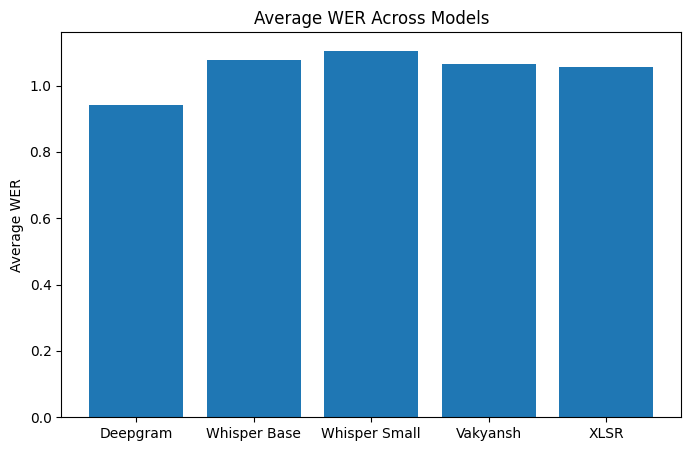

In [37]:
average_wer = {

    "Deepgram": results_df["Deepgram_WER"].mean(),

    "Whisper Base": results_df["WhisperBase_WER"].mean(),

    "Whisper Small": results_df["WhisperSmall_WER"].mean(),

    "Vakyansh": results_df["Vakyansh_WER"].mean(),

    "XLSR": results_df["XLSR_WER"].mean()
}

plt.figure(figsize=(8,5))

plt.bar(
    average_wer.keys(),
    average_wer.values()
)

plt.ylabel("Average WER")

plt.title("Average WER Across Models")

plt.show()

# Latency Graph

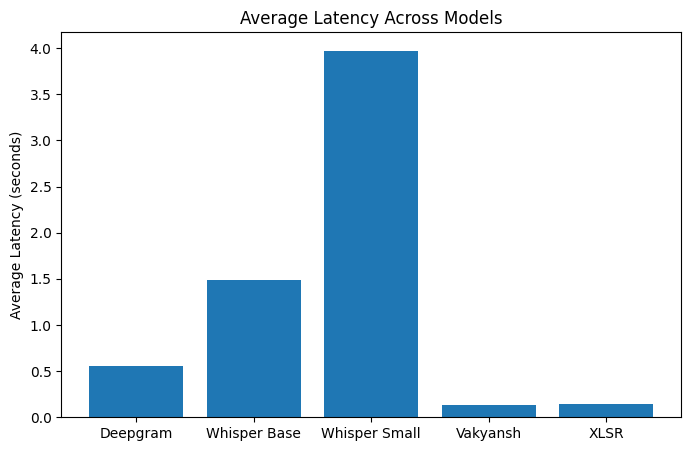

In [38]:
average_latency = {

    "Deepgram": results_df["Deepgram_Latency"].mean(),

    "Whisper Base": results_df["WhisperBase_Latency"].mean(),

    "Whisper Small": results_df["WhisperSmall_Latency"].mean(),

    "Vakyansh": results_df["Vakyansh_Latency"].mean(),

    "XLSR": results_df["XLSR_Latency"].mean()
}

plt.figure(figsize=(8,5))

plt.bar(
    average_latency.keys(),
    average_latency.values()
)

plt.ylabel("Average Latency (seconds)")

plt.title("Average Latency Across Models")

plt.show()

# Entity Accuracy Chart

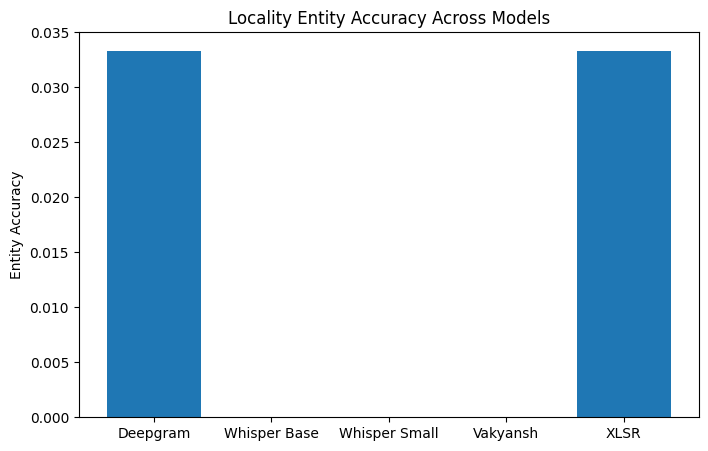

In [39]:
entity_scores = {

    "Deepgram": results_df["Deepgram_Entity_Accuracy"].mean(),

    "Whisper Base": results_df["WhisperBase_Entity_Accuracy"].mean(),

    "Whisper Small": results_df["WhisperSmall_Entity_Accuracy"].mean(),

    "Vakyansh": results_df["Vakyansh_Entity_Accuracy"].mean(),

    "XLSR": results_df["XLSR_Entity_Accuracy"].mean()
}

plt.figure(figsize=(8,5))

plt.bar(
    entity_scores.keys(),
    entity_scores.values()
)

plt.ylabel("Entity Accuracy")

plt.title("Locality Entity Accuracy Across Models")

plt.show()